In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#ensure the path of files is correct for this all to work correctly
from pathlib import Path
print("Notebook running from:", Path.cwd())

# ---- Project paths ----
ROOT = Path("..").resolve()     # one folder up from 'notebooks' → 'BBO'
DATA = ROOT / "data"


print("ROOT:", ROOT)
print("DATA:", DATA)
print("Contents of DATA:", [p.name for p in DATA.iterdir()])

Notebook running from: C:\Users\elena\Documents\BBO\notebooks
ROOT: C:\Users\elena\Documents\BBO
DATA: C:\Users\elena\Documents\BBO\data
Contents of DATA: ['F1', 'F2', 'F3', 'F4', 'F5', 'F6', 'F7', 'F8', 'function_summary.csv', '_old_function_summary.csv']


In [2]:
# pick which function to inspect
FN = "F4"   # change to F2..F8 later

# --- Read and print the description of the selected function ---
summary_path = DATA / "function_summary.csv" # path to your summary CSV
func_info = pd.read_csv(summary_path) # load it as a DataFrame
match = func_info.loc[func_info["Function"] == FN] # matches your function name (e.g., F1)
description = match["Description"].values[0] # extract the Description text
print(f"{FN} description:")
print(description)

df = pd.DataFrame(
    np.load(DATA / FN / "initial_inputs.npy"),
    columns=[f"x{i+1}" for i in range(np.load(DATA / FN / "initial_inputs.npy").shape[1])]
)
df["y"] = np.load(DATA / FN / "initial_outputs.npy")

display(df.head())
display(df.describe())

xs = [c for c in df.columns if c.startswith("x")]
summary = {
    "rows": len(df),
    "dims": len(xs),
    "bounds": {c: (float(df[c].min()), float(df[c].max())) for c in xs},
    "y_min": float(df["y"].min()),
    "y_max": float(df["y"].max()),
}
summary


F4 description:
Address the challenge of optimally placing products across warehouses for a business with high online sales, where accurate calculations are costly and only feasible biweekly. To speed up decision-making, an ML model approximates these results within hours. The model has four hyperparameters to tune, and its output reflects the difference from the expensive baseline. Because the system is dynamic and full of local optima, it requires careful tuning and robust validation to find reliable, near-optimal solutions.


,x1,x2,x3,x4,y
0,0.896981,0.725628,0.175404,0.701694,-22.108288
1,0.889356,0.499588,0.539269,0.508783,-14.601397
2,0.250946,0.033693,0.145380,0.494932,-11.699932
3,0.346962,0.006250,0.760564,0.613024,-16.053765
4,0.124871,0.129770,0.384400,0.287076,-10.069633


,x1,x2,x3,x4,y
count,30.000000,30.000000,30.000000,30.000000,30.000000
mean,0.542872,0.477129,0.465693,0.474096,-17.238587
std,0.294007,0.308910,0.261618,0.292412,7.137959
min,0.037825,0.006250,0.042186,0.081517,-32.625660
25%,0.258744,0.150459,0.223273,0.215885,-21.578590
50%,0.601918,0.499909,0.445999,0.499451,-16.040082
75%,0.787653,0.749126,0.708686,0.758504,-12.745906
max,0.985622,0.919592,0.939178,0.999483,-4.025542


{'rows': 30,
 'dims': 4,
 'bounds': {'x1': (0.03782482853334601, 0.9856218929694016),
  'x2': (0.006250400244917853, 0.9195923219593923),
  'x3': (0.04218634513719777, 0.9391779073552307),
  'x4': (0.08151656419033015, 0.9994825612275692)},
 'y_min': -32.625660215962455,
 'y_max': -4.025542281908162}

In [3]:
# --- save summary info + notes + timestamp to spreadsheet ---
sdf = pd.read_csv(DATA / "function_summary.csv")
note = f"Exploration: {summary['dims']}D, {summary['rows']} pts. y∈[{summary['y_min']:.6g},{summary['y_max']:.3g}]"
now  = pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S")

sdf.loc[sdf["Function"] == FN,
        ["Rows","Dims","Bounds","y_min","y_max","Best_y_so_far","Notes","Last_updated"]] = [
    summary["rows"], summary["dims"], str(summary["bounds"]),
    summary["y_min"], summary["y_max"], summary["y_max"], note, now
]

sdf.to_csv(DATA / "function_summary.csv", index=False)


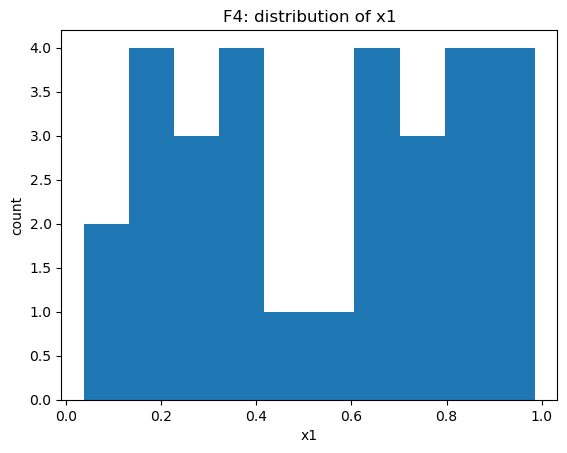

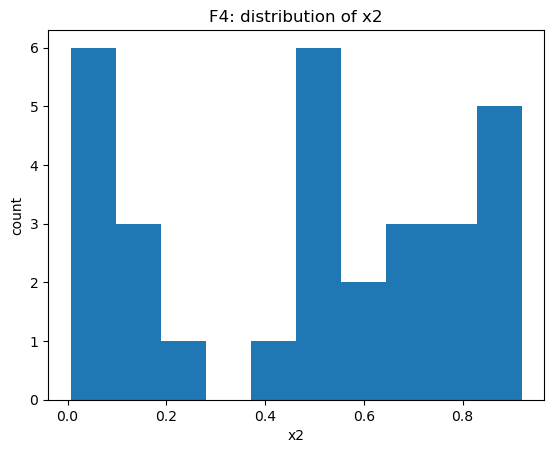

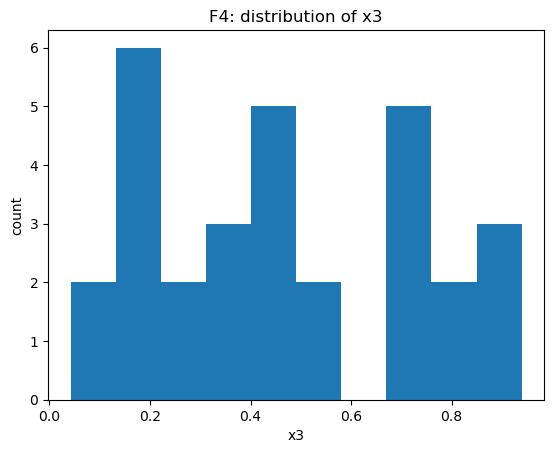

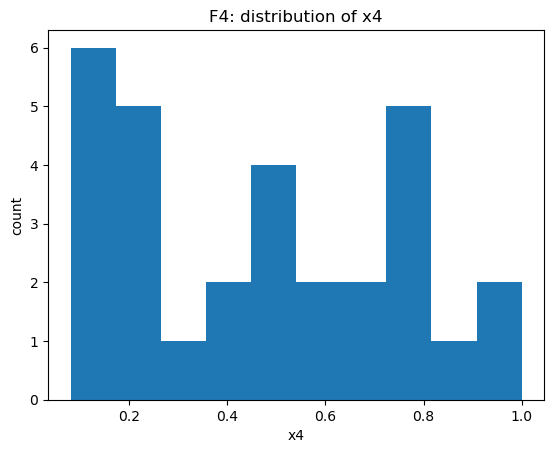

In [4]:
#Simple plot to see the points
xs = [c for c in df.columns if c.startswith("x")]
d = len(xs)

if d == 1:
    plt.figure()
    plt.scatter(df[xs[0]], df["y"])
    plt.xlabel(xs[0]); plt.ylabel("y"); plt.title(f"{FN}: y vs {xs[0]}")
    plt.show()

elif d == 2:
    plt.figure()
    sc = plt.scatter(df[xs[0]], df[xs[1]], c=df["y"])
    plt.xlabel(xs[0]); plt.ylabel(xs[1]); plt.title(f"{FN}: inputs colored by y")
    plt.colorbar(sc, label="y")
    plt.show()

else:
    # higher-D: show simple histograms so you see ranges
    for c in xs:
        plt.figure()
        plt.hist(df[c], bins=10)
        plt.xlabel(c); plt.ylabel("count"); plt.title(f"{FN}: distribution of {c}")
        plt.show()


In [5]:
df.corr(numeric_only=True)["y"].sort_values(ascending=False)

y     1.000000
x3   -0.084794
x2   -0.484809
x4   -0.532115
x1   -0.539888
Name: y, dtype: float64

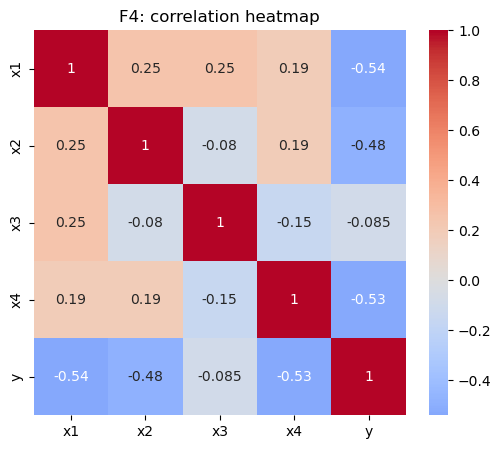

In [6]:
import seaborn as sns
corr = df.corr(numeric_only=True)
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title(f"{FN}: correlation heatmap")
plt.show()

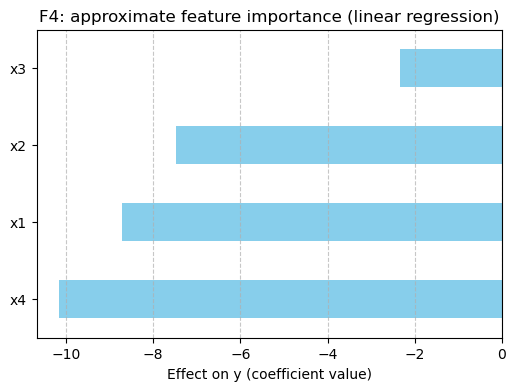

Feature coefficients:
x3    -2.336153
x2    -7.486801
x1    -8.705294
x4   -10.161057
dtype: float64


In [7]:
from sklearn.linear_model import LinearRegression
import numpy as np

# prepare data
X = df[["x1", "x2", "x3", "x4"]]
y = df["y"]

# fit simple linear model
model = LinearRegression().fit(X, y)

# get coefficients as feature importances
importance = pd.Series(model.coef_, index=X.columns)

# visualize
plt.figure(figsize=(6,4))
importance.sort_values().plot(kind="barh", color="skyblue")
plt.title(f"{FN}: approximate feature importance (linear regression)")
plt.xlabel("Effect on y (coefficient value)")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()

# print numeric values
print("Feature coefficients:")
print(importance.sort_values(ascending=False))


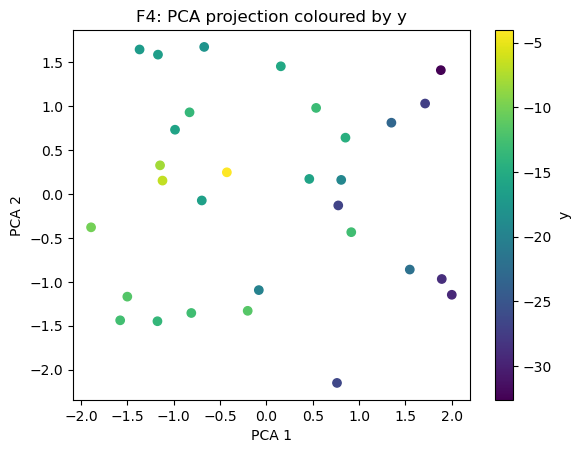

In [8]:
from sklearn.decomposition import PCA

X_std = (X - X.mean()) / X.std()
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_std)

plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap="viridis")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title(f"{FN}: PCA projection coloured by y")
plt.colorbar(label="y")
plt.show()


In [11]:
pd.DataFrame(pca.components_, columns=X.columns, index=["PCA1","PCA2"])


,x1,x2,x3,x4
PCA1,0.620078,0.585890,0.066075,0.517562
PCA2,0.400902,-0.175464,0.812379,-0.385396
